Let's get the data from [FMI Weather](https://en.ilmatieteenlaitos.fi/observation-stations)

This is just a proof of concept that this can work

In [1]:
#!pip install fmiopendata

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
from fmiopendata.wfs import download_stored_query
import requests

## Dataset

I have been researching to find the best stations across Finland's cities that would offer the best quality of data, but most of the observation center would either have missing features (`precipitation`, or `wind speed`).

So we will get multiple centers to compensate for this and merge them later into cities

Also we are getting the dataset from **Oulu, Helsinki, Tampere, Rovaniemi, and Vaasa** within the last 30 days, and we are also adding in the `latitude` and `longtitude` for each cities


Data was pulled from `02/03/2026`

In [3]:
# reliable_stations = {
#     "101786": {"city": "Oulu", "name": "Oulu Airport", "lat": 64.93, "lon": 25.35},
#     "101004": {"city": "Helsinki", "name": "Helsinki Kumpula", "lat": 60.20, "lon": 24.96},
#     "101118": {"city": "Tampere", "name": "Tampere Airport", "lat": 61.41, "lon": 23.60},
#     "101124": {"city": "Tampere", "name": "Tampere Harmala", "lat": 61.47, "lon": 23.75},
#     "100949": {"city": "Turku", "name": "Turku Artukainen", "lat": 60.51, "lon": 22.20},
#     "101933": {"city": "Rovaniemi", "name": "Rovaniemi Airport", "lat": 66.56, "lon": 25.83},
#     "101485": {"city": "Vaasa", "name": "Vaasa Klemettila", "lat": 63.09, "lon": 21.65},
#     "101462": {"city": "Vaasa", "name": "Vaasa Airport", "lat": 63.05, "lon": 21.76}
# }

# now = datetime.now()

# # Generate 30-day chunks for the last 3 years (1095 days)
# chunks = [(now - timedelta(days=i+30), now - timedelta(days=i)) for i in range(0, 1095, 30)]

# all_chunks_dfs = []
# count = 0
# for start, end in chunks:
#     starttime_str = start.strftime('%Y-%m-%dT%H:%M:%SZ')
#     endtime_str = end.strftime('%Y-%m-%dT%H:%M:%SZ')
#     all_dfs = []
#     count += 1
#     print(f"Fetching Window: {starttime_str} to {endtime_str}: [{count} / 37]")
#     for fmisid, info in reliable_stations.items():
#         try:
#             obs = download_stored_query("fmi::observations::weather::hourly::multipointcoverage",
#                                         args=[f"fmisid={fmisid}", 
#                                               f"starttime={starttime_str}", 
#                                               f"endtime={endtime_str}"])
#             if obs.data:
#                 rows = []
#                 for timestamp, stations in obs.data.items():
#                     for station_name, parameters in stations.items():
#                         row = {
#                             'time': timestamp,
#                             'city_group': info['city'],
#                             'station_name': info['name'],
#                             'lat': info['lat'],
#                             'lon': info['lon']
#                         }
#                         for p_name, p_data in parameters.items():
#                             row[p_name.replace(' ', '_').lower()] = p_data.get('value')
#                         rows.append(row)
#                 all_dfs.append(pd.DataFrame(rows))
#             time.sleep(1) # API Politeness
#         except Exception as e:
#             print(f"=========== Failed to retrieved: {e} ===============")
#             pass # Skip print to avoid console spam over 3 years

#     if all_dfs:
#         all_chunks_dfs.append(pd.concat(all_dfs, ignore_index=True))

# # Create the Raw Master DF
# df_raw = pd.concat(all_chunks_dfs, ignore_index=True)
# print("Ingestion Complete")

# df_raw.to_csv('weather_3_years.csv', index = False)

In [4]:
df_raw = pd.read_csv("weather_3_years.csv")

In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 212960 entries, 0 to 212959
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   time                             212960 non-null  str    
 1   city_group                       212960 non-null  str    
 2   station_name                     212960 non-null  str    
 3   lat                              212960 non-null  float64
 4   lon                              212960 non-null  float64
 5   air_temperature                  212896 non-null  float64
 6   highest_temperature              212919 non-null  float64
 7   lowest_temperature               212923 non-null  float64
 8   relative_humidity                212596 non-null  float64
 9   wind_speed                       184758 non-null  float64
 10  maximum_wind_speed               183869 non-null  float64
 11  minimum_wind_speed               183868 non-null  float64
 12  wind_directio

In [6]:
df_raw.isnull().sum()

time                                   0
city_group                             0
station_name                           0
lat                                    0
lon                                    0
air_temperature                       64
highest_temperature                   41
lowest_temperature                    37
relative_humidity                    364
wind_speed                         28202
maximum_wind_speed                 29091
minimum_wind_speed                 29092
wind_direction                     29261
precipitation_amount               79947
maximum_precipitation_intensity    80047
air_pressure                          60
present_weather_(auto)             26723
dtype: int64

In [7]:
df_raw['precipitation_amount'] = df_raw['precipitation_amount'].fillna(0)
df_raw['maximum_precipitation_intensity'] = df_raw['maximum_precipitation_intensity'].fillna(0)

wd_rad = np.deg2rad(df_raw['wind_direction'])
df_raw['u_wind'] = -df_raw['wind_speed'] * np.sin(wd_rad)
df_raw['v_wind'] = -df_raw['wind_speed'] * np.cos(wd_rad)

df_raw = df_raw.drop(columns=['wind_direction'])

df_city = df_raw.groupby(['time', 'city_group']).mean(numeric_only=True).reset_index()


df_city.isnull().sum()

time                                   0
city_group                             0
lat                                    0
lon                                    0
air_temperature                       33
highest_temperature                   26
lowest_temperature                    22
relative_humidity                    332
wind_speed                           844
maximum_wind_speed                   870
minimum_wind_speed                   871
precipitation_amount                   0
maximum_precipitation_intensity        0
air_pressure                          31
present_weather_(auto)             26642
u_wind                              1416
v_wind                              1416
dtype: int64

In [8]:

if 'present_weather_(auto)' in df_city.columns:
    df_city = df_city.drop(columns=['present_weather_(auto)'])


df_city = df_city.sort_values(by=['city_group', 'time'])

cols = df_city.columns.difference(['city_group', 'time'])
df_city[cols] = df_city.groupby('city_group')[cols].ffill(limit=6)


def calculate_dew_point(temp, rh):
    b = 17.625
    c = 243.04
    gamma = np.log(rh / 100) + (b * temp) / (c + temp)
    return (c * gamma) / (b - gamma)

df_city['dew_point'] = calculate_dew_point(df_city['air_temperature'], df_city['relative_humidity'])

df_city = df_city.dropna()
print("Final Clean Dataset Shape:", df_city.shape)
df_city.isnull().sum()

Final Clean Dataset Shape: (158827, 17)


time                               0
city_group                         0
lat                                0
lon                                0
air_temperature                    0
highest_temperature                0
lowest_temperature                 0
relative_humidity                  0
wind_speed                         0
maximum_wind_speed                 0
minimum_wind_speed                 0
precipitation_amount               0
maximum_precipitation_intensity    0
air_pressure                       0
u_wind                             0
v_wind                             0
dew_point                          0
dtype: int64

In [9]:

agg_dict = {
    'lat': 'first',
    'lon': 'first',
    'air_temperature': 'mean',
    'relative_humidity': 'mean',
    'wind_speed': 'mean',
    'precipitation_amount': 'sum', 
    'maximum_precipitation_intensity': 'max', # Keep this to flag heavy downpours
    'air_pressure': 'mean',
    'u_wind': 'mean',
    'v_wind': 'mean',
    'dew_point': 'mean'
}

df_city['time'] = pd.to_datetime(df_city['time'])
# df_city = df_city.set_index('time')

# # Group by city, resample to 3-hour intervals
# df_3h = df_city.groupby('city_group').resample('1h').agg(agg_dict).reset_index()

# # Sort to ensure chronological order
# df_3h = df_3h.sort_values(by=['city_group', 'time']).reset_index(drop=True)

df_city.info()

<class 'pandas.DataFrame'>
Index: 158827 entries, 0 to 159694
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   time                             158827 non-null  datetime64[us]
 1   city_group                       158827 non-null  str           
 2   lat                              158827 non-null  float64       
 3   lon                              158827 non-null  float64       
 4   air_temperature                  158827 non-null  float64       
 5   highest_temperature              158827 non-null  float64       
 6   lowest_temperature               158827 non-null  float64       
 7   relative_humidity                158827 non-null  float64       
 8   wind_speed                       158827 non-null  float64       
 9   maximum_wind_speed               158827 non-null  float64       
 10  minimum_wind_speed               158827 non-null  float64   

In [10]:
df_city.info()

<class 'pandas.DataFrame'>
Index: 158827 entries, 0 to 159694
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   time                             158827 non-null  datetime64[us]
 1   city_group                       158827 non-null  str           
 2   lat                              158827 non-null  float64       
 3   lon                              158827 non-null  float64       
 4   air_temperature                  158827 non-null  float64       
 5   highest_temperature              158827 non-null  float64       
 6   lowest_temperature               158827 non-null  float64       
 7   relative_humidity                158827 non-null  float64       
 8   wind_speed                       158827 non-null  float64       
 9   maximum_wind_speed               158827 non-null  float64       
 10  minimum_wind_speed               158827 non-null  float64   

## Atmospheric Physics: Historical Training vs. Production Inference

To give our XGBoost model a true understanding of the weather from [**FMI's explaination**](https://en.ilmatieteenlaitos.fi/climate-elements), we injected atmospheric physics features like **Cloud Cover** and **Solar Radiation**. However, our data pipeline for these features must change between the Training phase and the Production phase.

### 1. Training Phase
For our 3-year historical dataset, we use the **Open-Meteo Archive API** to fetch **ERA5** data.
* **What is it?** ERA5 is the 5th generation ECMWF atmospheric reanalysis. It is the global gold standard for historical climate data, blending physical sensor networks with satellite imagery.


### 2. Production Phase
* ERA5 reanalysis requires massive supercomputer processing, resulting in a **2 to 5-day release delay**. Therefore, it is impossible to use ERA5 for live, real-time predictions.
* **The Production Solution:** When this model is deployed via our automated GitHub Action, the pipeline will seamlessly switch to the **Open-Meteo Forecast API**. 




In [11]:


# # 1. Get dates and coordinates from existing data
# start_date = df_3h['time'].min().strftime('%Y-%m-%d')
# end_date = df_3h['time'].max().strftime('%Y-%m-%d')
# city_coords = df_3h.groupby('city_group')[['lat', 'lon']].first().reset_index()

# era5_dfs = []

# print(f"Fetching ERA5 Data from {start_date} to {end_date}...")

# # 2. Fetch data for each city
# for _, row in city_coords.iterrows():
#     city = row['city_group']
#     print(f"Pulling radiation and clouds for {city}...")
    
#     url = "https://archive-api.open-meteo.com/v1/archive"
#     params = {
#         "latitude": row['lat'],
#         "longitude": row['lon'],
#         "start_date": start_date,
#         "end_date": end_date,
#         "hourly": "cloudcover,shortwave_radiation",
#         "timezone": "UTC"
#     }
    
#     response = requests.get(url, params=params).json()
    
#     # 3. Build dataframe
#     df_temp = pd.DataFrame(response['hourly'])
#     df_temp['time'] = pd.to_datetime(df_temp['time'], utc=True)
#     df_temp['city_group'] = city
    
#     era5_dfs.append(df_temp)
#     time.sleep(1) # API politeness

# # Combine all hourly ERA5 data
# df_era5_hourly = pd.concat(era5_dfs, ignore_index=True)

# df_era5_hourly.to_csv("era5.csv", index = False)

In [12]:
df_city.info()

<class 'pandas.DataFrame'>
Index: 158827 entries, 0 to 159694
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   time                             158827 non-null  datetime64[us]
 1   city_group                       158827 non-null  str           
 2   lat                              158827 non-null  float64       
 3   lon                              158827 non-null  float64       
 4   air_temperature                  158827 non-null  float64       
 5   highest_temperature              158827 non-null  float64       
 6   lowest_temperature               158827 non-null  float64       
 7   relative_humidity                158827 non-null  float64       
 8   wind_speed                       158827 non-null  float64       
 9   maximum_wind_speed               158827 non-null  float64       
 10  minimum_wind_speed               158827 non-null  float64   

In [13]:


df_era5_hourly = pd.read_csv("era5.csv")
print("Before Merging", df_city.shape)

df_era5_hourly['time'] = pd.to_datetime(df_era5_hourly['time'], utc=True)


df_era5_3h = (
    df_era5_hourly.set_index('time')
    .groupby('city_group')
    .resample('1h')
    .mean(numeric_only=True)
    .reset_index()
)


df_city['time'] = pd.to_datetime(df_city['time'], utc=True)


df = pd.merge(df_city, df_era5_3h, on=['city_group', 'time'], how='left')

print("After merging", df.shape)

Before Merging (158827, 17)
After merging (158827, 19)


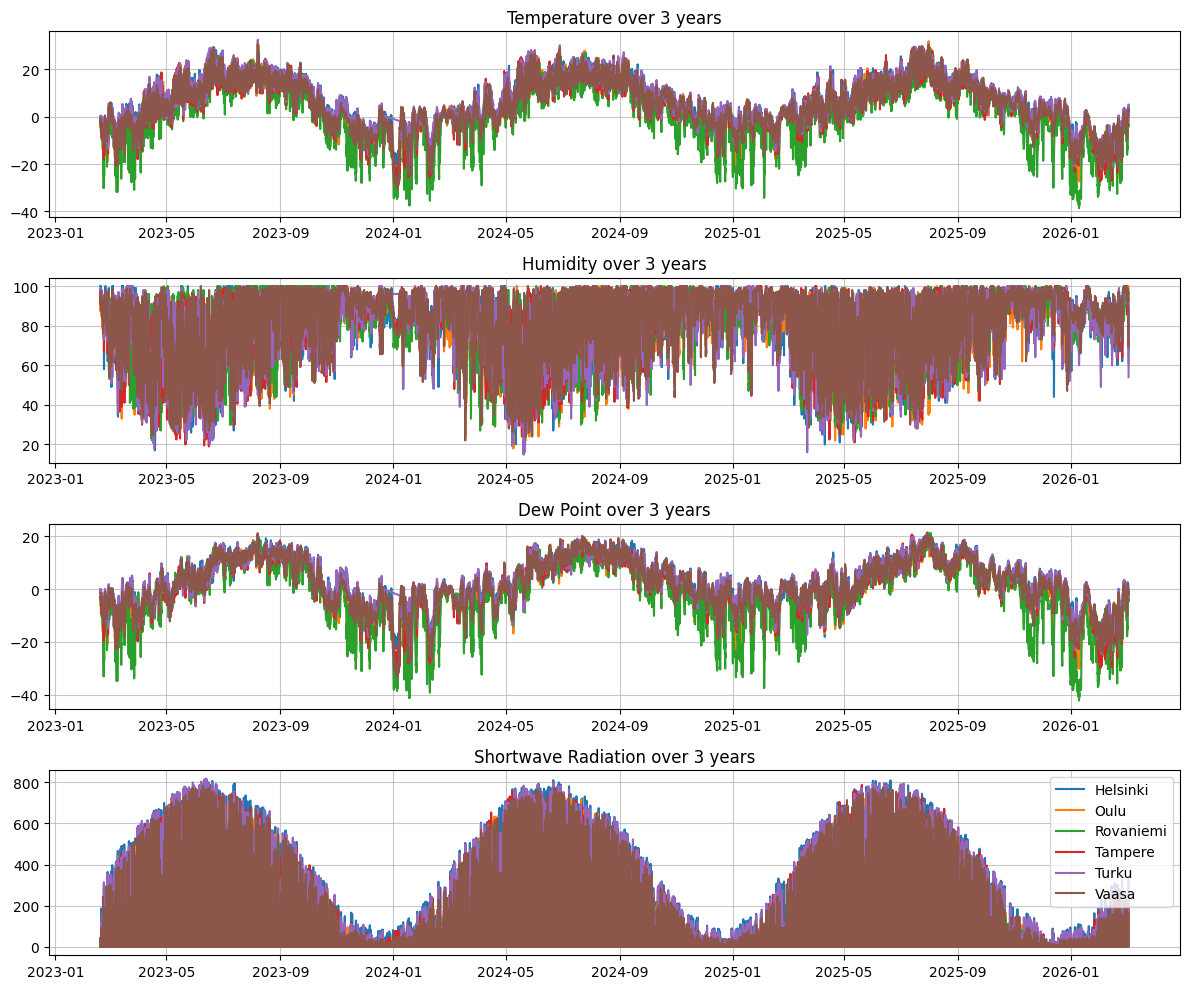

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize= (12, 10))

plt.subplot(4, 1, 1)
for city in df['city_group'].unique():
    city_data = df[df['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['air_temperature'], label = city)

plt.title("Temperature over 3 years")
plt.grid(alpha = 0.7)


plt.subplot(4, 1, 2)
for city in df['city_group'].unique():
    city_data = df[df['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['relative_humidity'], label = city)
    
plt.title("Humidity over 3 years")
plt.grid(alpha = 0.7)

plt.subplot(4, 1, 3)
for city in df['city_group'].unique():
    city_data = df[df['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['dew_point'], label = city)
    
plt.title("Dew Point over 3 years")
plt.grid(alpha = 0.7)

plt.subplot(4, 1, 4)
for city in df['city_group'].unique():
    city_data = df[df['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['shortwave_radiation'], label = city)

plt.title("Shortwave Radiation over 3 years")
plt.legend()
plt.grid(alpha = 0.7)


plt.tight_layout()
plt.show()

In [15]:
df = df.sort_values(by= ['city_group', 'time']).reset_index(drop = True)

df['pressure_trend_3h'] = df.groupby(['city_group'])['air_pressure'].diff(periods= 1)
df['pressure_trend_6h'] = df.groupby(['city_group'])['air_pressure'].diff(periods= 2)
df['pressure_trend_12h'] = df.groupby(['city_group'])['air_pressure'].diff(periods= 4)

df['day'] = df['time'].dt.day_of_year
# df['month'] = df['time'].dt.month
df['hour'] = df['time'].dt.hour

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
# df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 365.25)

coastal_distances = {
    'Oulu': 0, 'Helsinki': 0, 'Turku': 0, 'Vaasa': 0, 
    'Tampere': 130, 'Rovaniemi': 100 
}

df['coastal_dist'] = df['city_group'].map(coastal_distances)


df = df.dropna()



### Model Feature Set

| Category | Feature Name | DataFrame Column | Origin | ML Purpose |
| --- | --- | --- | --- | --- |
| **Ground Truth** | Mean Temperature | `air_temperature` | FMI | The baseline thermal measurement. |
| **Ground Truth** | Relative Humidity | `relative_humidity` | FMI | Core moisture metric. |
| **Ground Truth** | Mean Wind Speed | `wind_speed` | FMI | Captures thermal mixing and advection. |
| **Ground Truth** | Mean Air Pressure | `air_pressure` | FMI | The baseline for atmospheric mass. |
| **Ground Truth** | Precipitation Total | `precipitation_amount` | FMI | Total water/snow fallen in the 3h window. |
| **Ground Truth** | Max Precip Intensity | `maximum_precipitation_intensity` | FMI | Flags sudden, heavy downpours or blizzards. |
| **Vector Physics** | U-Wind (East/West) | `u_wind` | Calculated | Removes the 360° jump; tells the model if the wind is blowing from Russia. |
| **Vector Physics** | V-Wind (North/South) | `v_wind` | Calculated | Tells the model if the wind is blowing from the Arctic. |
| **Derived Physics** | Dew Point | `dew_point` | Calculated | The exact temperature where condensation occurs. |
| **Derived Physics** | Dew Point Depression | `dew_point_depression` | Calculated | When $T - T_{dp}$ hits 0, the model knows to expect fog/precipitation. |
| **Momentum** | 3-Hour Pressure Trend | `pressure_trend_3h` | Calculated | Detects fast-moving local weather fronts. |
| **Momentum** | 6-Hour Pressure Trend | `pressure_trend_6h` | Calculated | Detects incoming regional systems. |
| **Momentum** | 12-Hour Pressure Trend | `pressure_trend_12h` | Calculated | The #1 predictor of major Westerly Disturbances. |
| **Atmospheric** | Cloud Cover | `cloudcover` | ERA5 (API) | Tells the model if the sky is acting as a thermal blanket. |
| **Atmospheric** | Solar Radiation | `shortwave_radiation` | ERA5 (API) | Captures exact solar heating hitting the ground (replaces `solar_elevation`). |
| **Cyclical Time** | Daily Sine/Cosine | `sin_hour`, `cos_hour` | Calculated | Allows the model to understand the 24-hour cycle (Hour 23 is next to Hour 0). |
| **Cyclical Time** | Yearly Sine/Cosine | `sin_day`, `cos_day` | Calculated | Allows the model to map the seasons. |
| **Geospatial** | Distance to Coast | `dist_to_coast_km` | Static Map | Captures the thermal buffering effect of the sea. |
| **Geospatial** | Coordinates | `lat`, `lon` | FMI | Maps the North-South temperature gradient. |



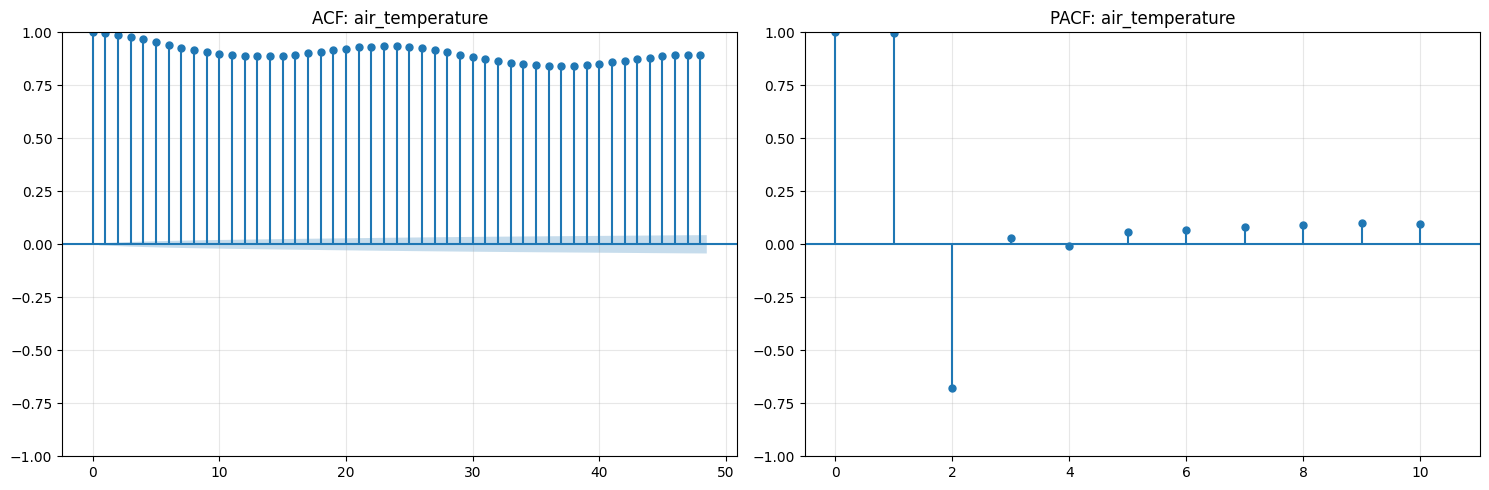

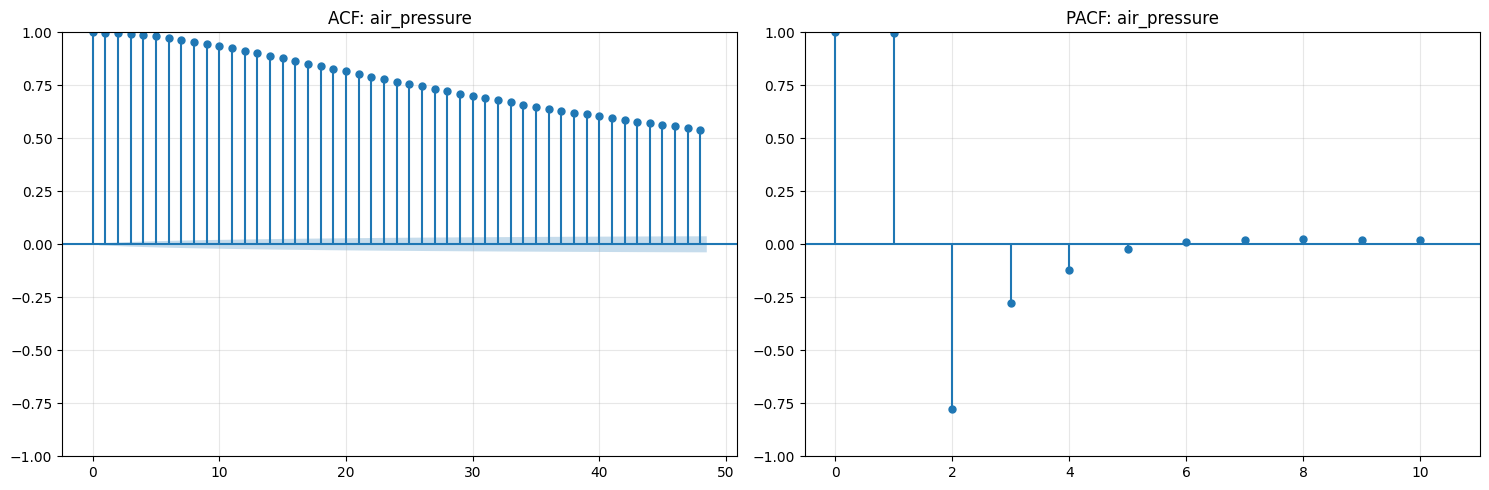

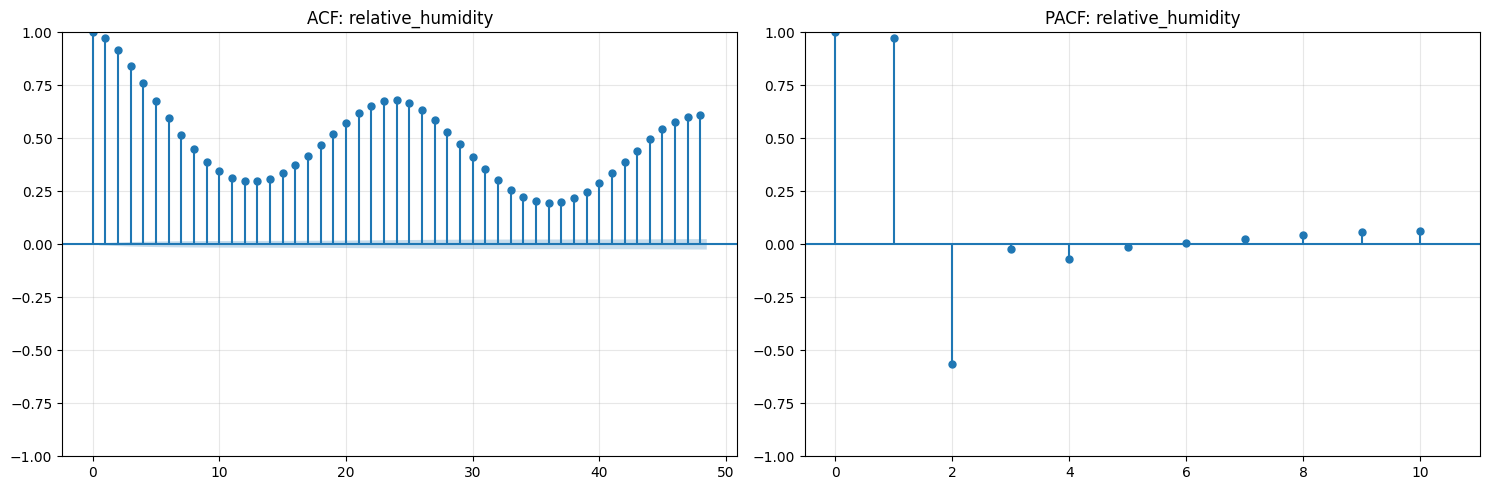

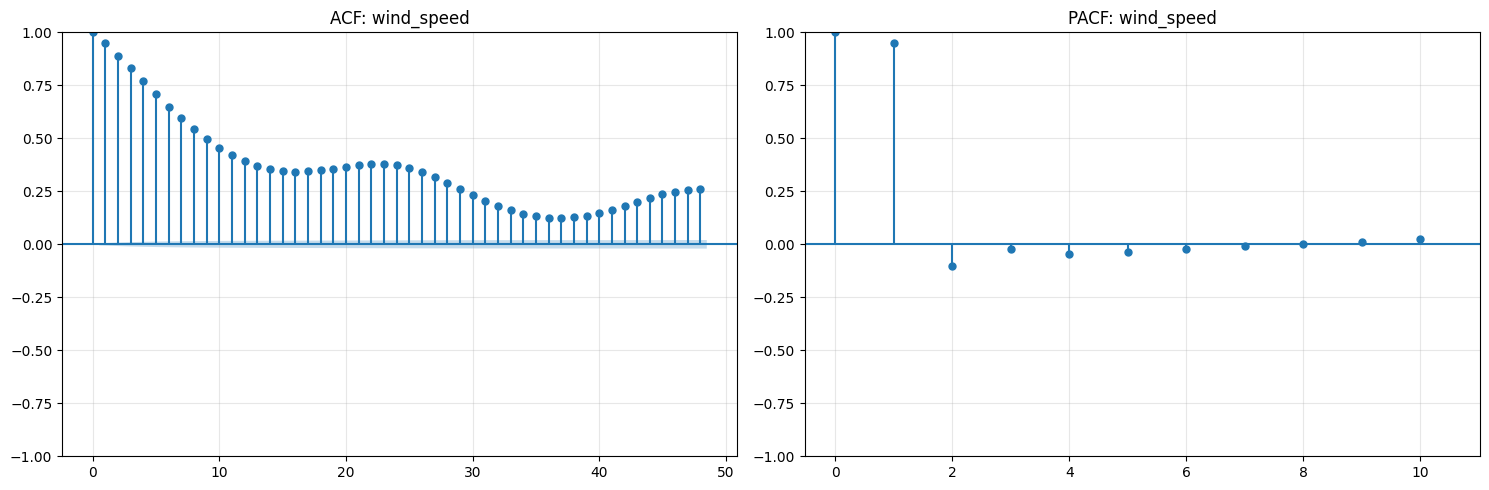

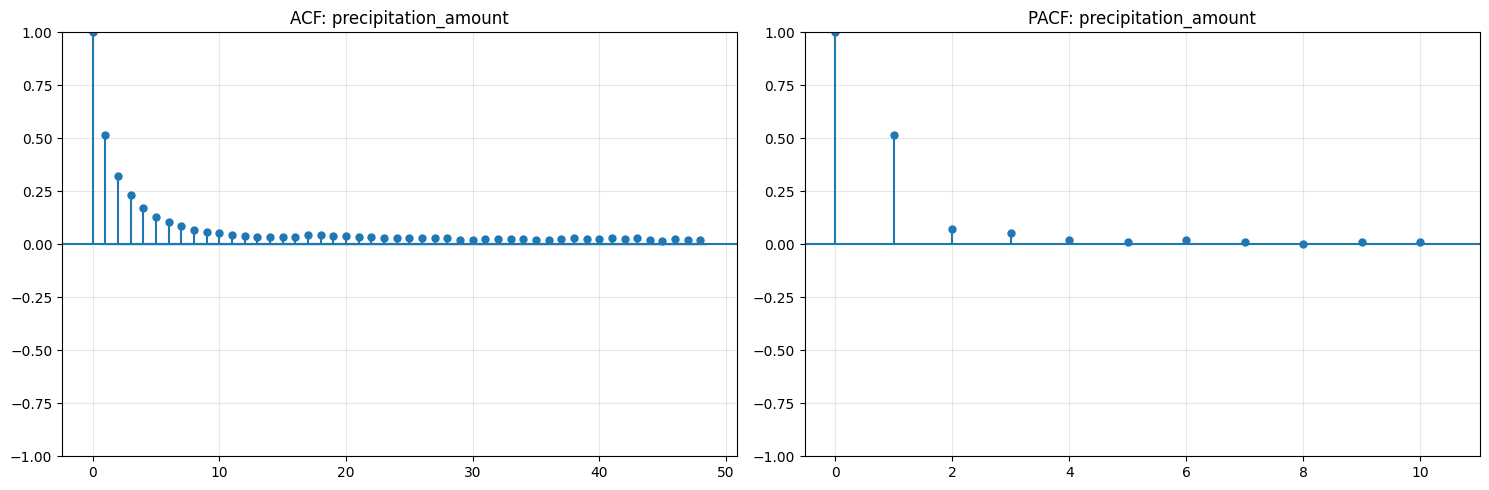

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


feature_to_check = [
    'air_temperature', 'air_pressure', 'relative_humidity', 
    'wind_speed', 'precipitation_amount'
]


for feat in feature_to_check:
    series = df[feat].copy()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    

    plot_acf(series, lags=48, ax=ax1)
    ax1.set_title(f'ACF: {feat}')
    ax1.grid(alpha=0.3)

    plot_pacf(series, lags=10, ax=ax2, method='ywm')
    ax2.set_title(f'PACF: {feat}')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [17]:
target_col = []

for h in [3, 6, 12]:
    col_name = f'target_{h * 2}h'
    df[col_name] = df.groupby('city_group')['air_temperature'].shift(-h)
    target_col.append(col_name)

df = df.dropna()

In [ ]:
feature = [

    'air_temperature', 
    'relative_humidity', 'wind_speed', 
    'air_pressure', 
    'dew_point',
    # 'precipitation_amount', 'maximum_precipitation_intensity',

    'u_wind', 'v_wind',
    'cloudcover', 'shortwave_radiation',    
    # 'pressure_trend_3h', 'pressure_trend_6h', 'pressure_trend_12h',
    'hour_sin', 'hour_cos', 
    'day_sin', 'day_cos',

    'lat', 'lon', 'coastal_dist'
]


train_list, val_list, test_list = [], [], []

# stratified split so that we have a balanced amount of data from each cities 
# within the train, val, test set
for city in df['city_group'].unique():
    city_df = df[df['city_group'] == city].sort_values('time')
    
    n = len(city_df)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    
    train_list.append(city_df.iloc[:train_end])
    val_list.append(city_df.iloc[train_end:val_end])
    test_list.append(city_df.iloc[val_end:])

train_df = pd.concat(train_list)
val_df = pd.concat(val_list)
test_df = pd.concat(test_list)

X_train, X_val, X_test = train_df[feature], val_df[feature], test_df[feature]
y_train, y_val, y_test = train_df[target_col], val_df[target_col], test_df[target_col]

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(111110, 15) (23808, 15) (23813, 15)
(111110, 3) (23808, 3) (23813, 3)


In [43]:
# Check how many rows of each city are in each split
for name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name} Split:")
    print(split_df['city_group'].value_counts())


Train Split:
city_group
Oulu         18635
Vaasa        18635
Tampere      18627
Helsinki     18594
Rovaniemi    18497
Turku        18122
Name: count, dtype: int64

Val Split:
city_group
Oulu         3993
Vaasa        3993
Tampere      3991
Helsinki     3984
Rovaniemi    3964
Turku        3883
Name: count, dtype: int64

Test Split:
city_group
Oulu         3994
Vaasa        3994
Tampere      3992
Helsinki     3985
Rovaniemi    3964
Turku        3884
Name: count, dtype: int64


In [44]:
from xgboost import XGBRegressor
models = {}
val_predicts = {}


for col in target_col:
    xgb = XGBRegressor(
        random_state = 8,
        n_estimators = 1000,
        learning_rate = 0.01,
        eval_metric = ['mae'],
        early_stopping_rounds = 50,
    )

    xgb.fit(X_train, y_train[col],
            eval_set = [(X_val, y_val[col])],
            verbose = 100)

    y_pred = xgb.predict(X_val)

    models[col] = xgb
    val_predicts[col] = y_pred

    print(f"Complete model for {col}\n\n")


[0]	validation_0-mae:8.83458
[100]	validation_0-mae:3.43163
[200]	validation_0-mae:1.69593
[300]	validation_0-mae:1.23985
[400]	validation_0-mae:1.12617
[500]	validation_0-mae:1.08581
[600]	validation_0-mae:1.05937
[700]	validation_0-mae:1.04272
[800]	validation_0-mae:1.03403
[900]	validation_0-mae:1.02830
[999]	validation_0-mae:1.02540
Complete model for target_6h


[0]	validation_0-mae:8.83700
[100]	validation_0-mae:3.61349
[200]	validation_0-mae:2.08491
[300]	validation_0-mae:1.71189
[400]	validation_0-mae:1.60588
[500]	validation_0-mae:1.56216
[600]	validation_0-mae:1.54024
[700]	validation_0-mae:1.52698
[800]	validation_0-mae:1.51752
[900]	validation_0-mae:1.51277
[999]	validation_0-mae:1.50732
Complete model for target_12h


[0]	validation_0-mae:8.83413
[100]	validation_0-mae:3.79420
[200]	validation_0-mae:2.42819
[300]	validation_0-mae:2.10444
[400]	validation_0-mae:1.99882
[500]	validation_0-mae:1.95255
[600]	validation_0-mae:1.93057
[700]	validation_0-mae:1.91293
[800]	validat

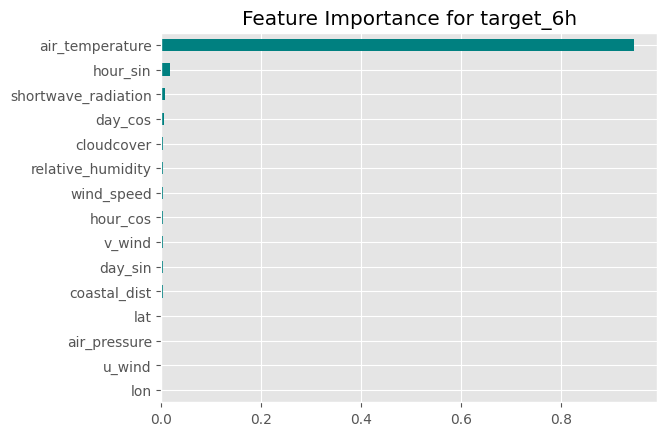

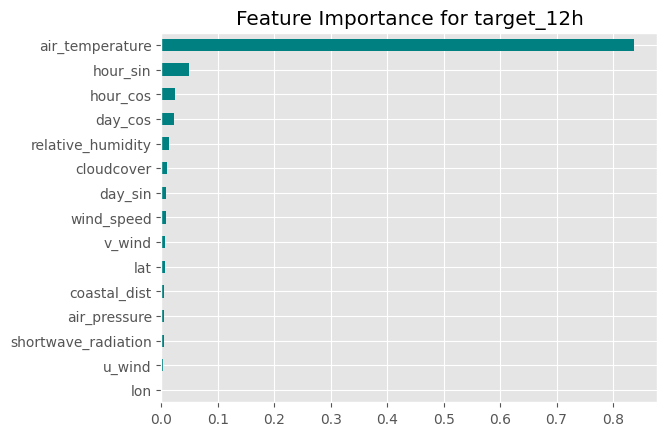

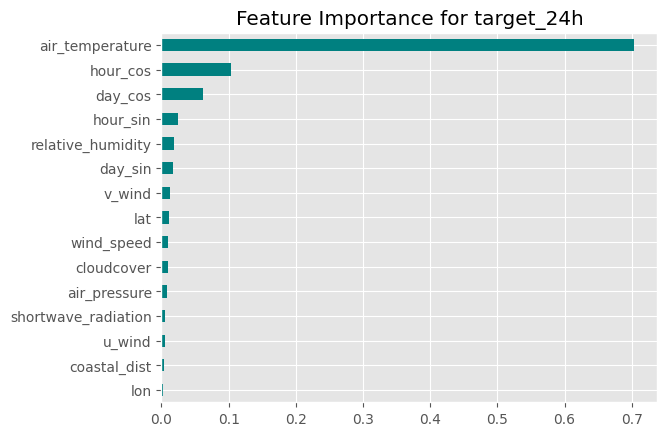

In [45]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Set style
plt.style.use('ggplot')

for col in target_col:
    # 1. Get the underlying booster from the XGBRegressor
    model = models[col]
    
    
    feat_imp = pd.Series(model.feature_importances_, index = feature).sort_values()
    feat_imp.plot(kind = 'barh', color = "teal")
    plt.title(f"Feature Importance for {col}")
    plt.show()

In [46]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

for col in target_col:
    rmse = root_mean_squared_error(y_true = y_val[col], y_pred= val_predicts[col])
    mae = mean_absolute_error(y_true = y_val[col], y_pred= val_predicts[col])
    r2 = r2_score(y_true= y_val[col], y_pred= val_predicts[col])
    print(f"Metrics for {col} model:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"r2 : {r2:.2f}")
    print("=============================")


Metrics for target_6h model:
RMSE: 1.35
MAE: 1.03
r2 : 0.96
Metrics for target_12h model:
RMSE: 1.94
MAE: 1.51
r2 : 0.92
Metrics for target_24h model:
RMSE: 2.43
MAE: 1.89
r2 : 0.87


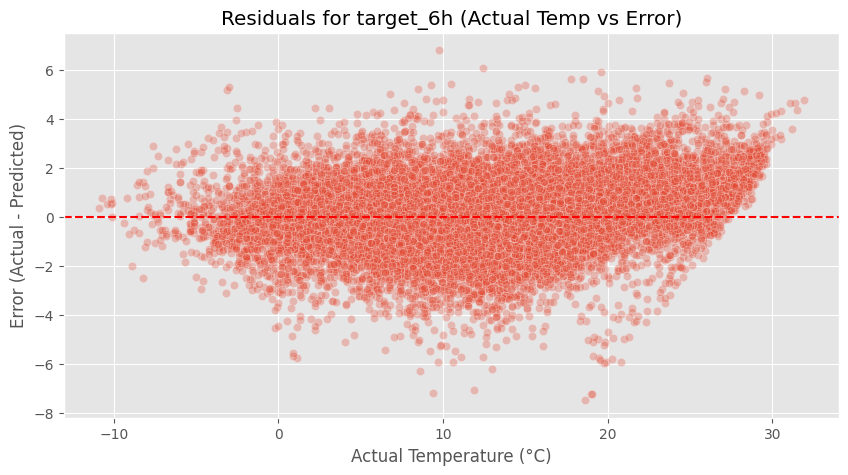

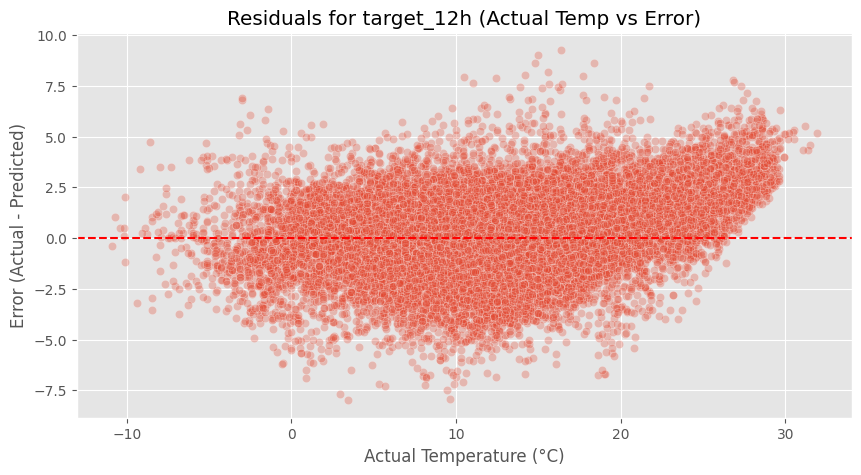

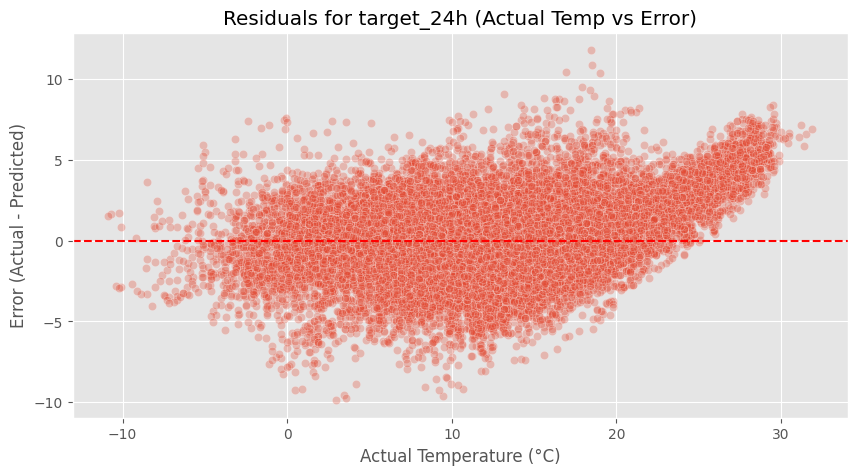

In [47]:
import seaborn as sns

for col in target_col:
    plt.figure(figsize=(10, 5))
    residuals = y_val[col] - val_predicts[col]
    
    sns.scatterplot(x=y_val[col], y=residuals, alpha=0.3)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residuals for {col} (Actual Temp vs Error)')
    plt.xlabel('Actual Temperature (°C)')
    plt.ylabel('Error (Actual - Predicted)')
    plt.show()

In [48]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

test_predictions = {}

for col in target_col:
    # 1. Access the model
    xgb_model = models[col]
    
    
    pred = xgb_model.predict(X_test)

    # 4. Metrics: Use y_test for BOTH true values
    rmse = root_mean_squared_error(y_true=y_test[col], y_pred=pred)
    mae = mean_absolute_error(y_true=y_test[col], y_pred=pred) # Changed y_val to y_test
    r2 = r2_score(y_true=y_test[col], y_pred=pred) # Changed y_val to y_test
    
    print(f"Metrics for {col} model:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"r2 : {r2:.2f}")
    print("=============================")
    test_predictions[col] = pred

Metrics for target_6h model:
RMSE: 1.35
MAE: 0.95
r2 : 0.98
Metrics for target_12h model:
RMSE: 2.14
MAE: 1.54
r2 : 0.95
Metrics for target_24h model:
RMSE: 3.29
MAE: 2.38
r2 : 0.89


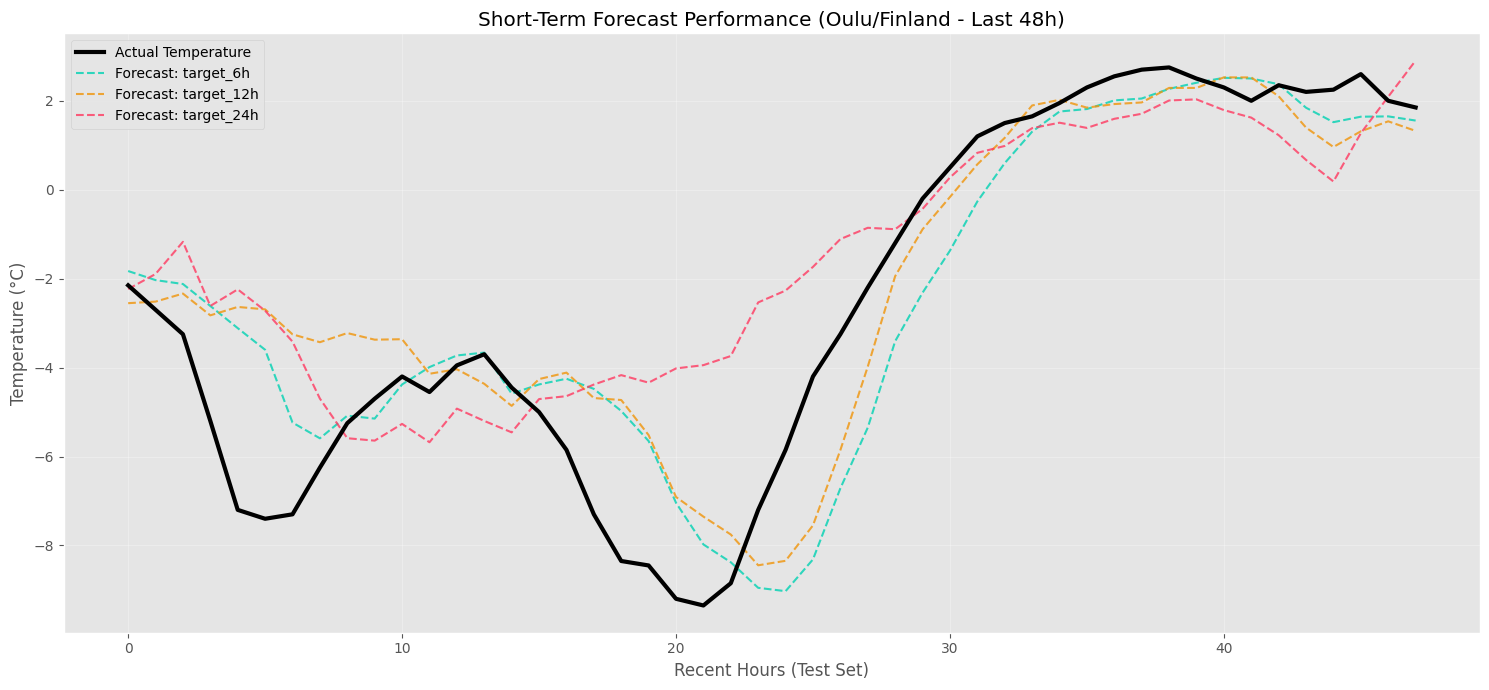

In [49]:
window = 48 
time_axis = range(window)

plt.figure(figsize=(15, 7))

plt.plot(
    time_axis, 
    y_test['target_6h'].iloc[-window:].values, 
    label='Actual Temperature', 
    color='black', 
    linewidth=3, 
    zorder=5
)

colors = ['#00d1b2', "#f09409", '#ff3860'] # 6h, 12h, 24h colors
for i, col in enumerate(target_col):

    y_xgb = test_predictions[col] 
    
    plt.plot(
        time_axis, 
        y_xgb[-window:], 
        linestyle='--', 
        color=colors[i],
        label=f'Forecast: {col}',
        alpha=0.8
    )
    

plt.title(f"Short-Term Forecast Performance (Oulu/Finland - Last {window}h)")
plt.xlabel("Recent Hours (Test Set)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# import joblib


# model_path = "models/weather_model_1to3h.joblib"
# joblib.dump(xgb, model_path)

# print(f"Model saved successfully as: {model_path}")